# Spectral Clustering

It can find clusters with "difficult" geometris (for kmeans)

**Step 1**: build a graph from $x_1,\ldots,x_n$

**Step 2**: build the Laplacian matrix

**Step 3**: compute eigenvalues and eigenvectors

$\lambda_1\geq\ldots\geq\lambda_n\geq 0$

$q_1,\ldots,q_n$

**Step 4**: Define $Y=[q_n | q_{n-1} |\ldots|q_{n-k+1}]$ where $k$ is the number of clusters. Then plot the rows of $Y$. This, for some reason, maps our clusters to separated blobs.

**Step 5**: apply kmeans to the rows of $Y$

**But why does Step 4 work?**

Ideal case: the clusters are infinitely far apart.

In this case, the Laplacian will be block diagonal. So $\lambda_{n-1}=\lambda_n=0$, and the eigenvectors will correspond to the connected components. So we have $ Y = [q_n|q_{n-1}] $,
the rows of which are either (0,1) or (1,0)
    

In the general case: we can write our Laplacian as the ideal case plus a 'small' perturbation. We have a theorem (Davis-Kahan) that says the e-vectors $q_{n-1},q_n$ are not even close to those of the ideal laplacian, but their span is similar. This will imply that $[q_{n-1}|q_n]\sim [e_{n-1}e_{n}]Q$, for orthogonal Q$. Thus our clusters will be approximately 90 degrees from each other.

    

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import eigh

In [3]:
# k- means function
def kmeans(X,k):
    
    from sklearn.metrics import pairwise_distances
    # initialize iteration counter
    it = 0

    max_iterations=1000 # if it=1000, we'll stop kmeans
    repeat=True # when centers stop moving, we'll set repeat = False
    
    # size of X
    m,n = X.shape 
    
    
    # kmeans initialization
    centers = X[np.random.choice(m,k)] 
    dist = pairwise_distances(X,centers)
    clusters = np.argmin(dist, axis=1)
 
    # while repeat = True and it<1000, repeat kmeans steps
    while repeat and it<max_iterations:
        
        # update means; # if a cluster has no points associated with it, replace it with a random point
        centers = np.array([np.mean(X[clusters==i], axis=0) 
                          if np.sum(clusters==i)!=0 
                          else  X[np.random.choice(m,1)] # 
                          for i in range(k)])
        
        # update clusters
        dist = pairwise_distances(X,centers)
        new_clusters = np.argmin(dist, axis=1)
        
        # check if the new clusters are equal to the previous clusters
        if np.sum(clusters!=new_clusters)==0: 
            repeat = False
        clusters = new_clusters
              
        # increment iteration counter by 1    
        it += 1 

    return clusters, centers

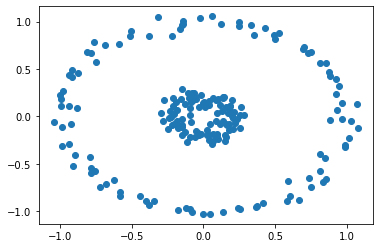

In [6]:
# homework 2 example
from sklearn.datasets import make_circles
X,y = make_circles(n_samples= 200, noise=0.05, factor=0.2)
plt.scatter(X[:,0],X[:,1])

In [8]:
# Let's try kmeans
k = 2
clusters, centers = kmeans(X,k)

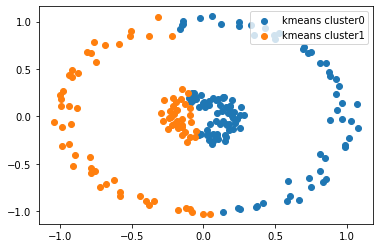

In [9]:
# plot kmeans results
for i in range(k):
    plt.scatter(X[clusters==i,0], X[clusters==i,1], label = 'kmeans cluster'+str(i))
plt.legend()

That didn't work, let's try Spectral Clustering!

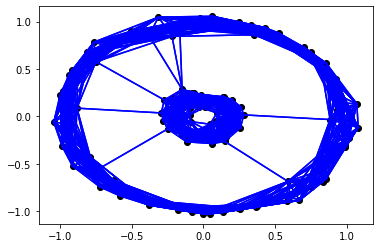

In [12]:
# build a graph
from sklearn.metrics import pairwise_distances
distances = pairwise_distances(X)
n_neighbors = 20
neighbors = np.argsort(distances,axis=1)[:,1:n_neighbors+1]
A = np.zeros((200,200))
for i in range(200):
    A[i,neighbors[i]]=1
    A[neighbors[i],i]=1
    
# draw the graph
plt.scatter(X[:,0],X[:,1],color='black')
for i in range(200): # loop over the nodes
    for j in np.where(A[i]==1)[0]: #loop over the neighbors of node i
        plt.plot(X[[i,j],0],X[[i,j],1],color='blue')

In [14]:
# Laplacian
L = np.diag(np.sum(A,axis=1))-A

#eigenvalues/eigenvectors

D,V = eigh(L)
# k eigenvectors with smallest eigenvalues
Y = V[:,0:k]

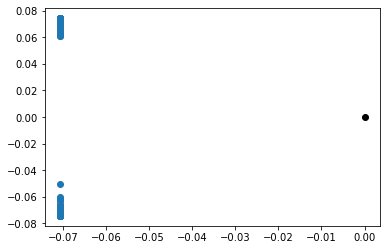

In [16]:
#plot rows of Y
plt.scatter(Y[:,0],Y[:,1])
plt.scatter(0,0,color='black')

In [17]:
clusters,centers=kmeans(Y,k)

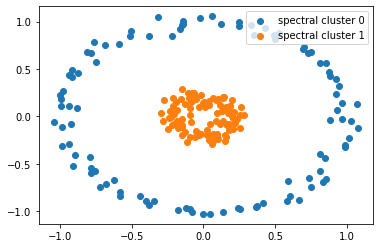

In [19]:
for i in range(k):
    plt.scatter(X[clusters==i,0],X[clusters==i,1],label = 'spectral cluster '+str(i))
    plt.legend()